# Lab 6a: Membership Inference Attack
Bethany Amanuel, bes5ve, SYS 5581  

## 0. Setup and Imports
This section imports the packages used throughout the notebook

In [2]:
import math
import random
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    roc_curve,
    roc_auc_score,
    confusion_matrix,
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

%matplotlib inline

SEED = 5581
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Target Model Description

This section covers:
- dataset used
- member / non-member split
- model architecture
- hyperparameters
- training and test accuracy for both models

## Dataset choice
I used the Breast Cancer Wisconsin dataset from scikit-learn. It is a tabular binary classification dataset with 30 numeric features and 569 rows total. It trains quickly and it still shows the privacy pattern needed for membership inference.

In [3]:
'''Load dataset'''
data = load_breast_cancer()
X = data.data
y = data.target
feature_names = data.feature_names

# Put the features into a dataframe for inspection
df = pd.DataFrame(X, columns=feature_names)
df["label"] = y

print("Dataset shape:", df.shape)
print("\nClass distribution:")
print(df["label"].value_counts().sort_index())
df.head()

Dataset shape: (569, 31)

Class distribution:
label
0    212
1    357
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,label
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


## Member / non-member split
The target model is trained on members and attacked using a held-out non-member set of equal size.

I split the data in two stages:
1. A first split creates a member pool and non-member pool of equal size.
2. A second split creates:
   - a member evaluation set
   - a non-member calibration set for threshold selection
   - a non-member evaluation set for final attack metrics

This is slightly stronger than choosing the threshold directly on the final evaluation points, because it separates threshold tuning from final reporting.

In [4]:
'''First: split into member and non-member pools of equal size'''
X_member_pool, X_nonmember_pool, y_member_pool, y_nonmember_pool = train_test_split(
    X,
    y,
    test_size=0.50,
    stratify=y,
    random_state=SEED,
)

print("Member pool size:", len(X_member_pool))
print("Non-member pool size:", len(X_nonmember_pool))

'''Second: split the member pool into actual training members and held-out member evaluation points'''
X_member_train, X_member_eval, y_member_train, y_member_eval = train_test_split(
    X_member_pool,
    y_member_pool,
    test_size=0.50,
    stratify=y_member_pool,
    random_state=SEED,
)

'''Split non-members into calibration and final evaluation sets'''
X_nonmember_cal, X_nonmember_eval, y_nonmember_cal, y_nonmember_eval = train_test_split(
    X_nonmember_pool,
    y_nonmember_pool,
    test_size=0.50,
    stratify=y_nonmember_pool,
    random_state=SEED,
)

print("\nTarget model training set (members):", len(X_member_train))
print("Member evaluation set:", len(X_member_eval))
print("Non-member calibration set:", len(X_nonmember_cal))
print("Non-member evaluation set:", len(X_nonmember_eval))

Member pool size: 284
Non-member pool size: 285

Target model training set (members): 142
Member evaluation set: 142
Non-member calibration set: 142
Non-member evaluation set: 143


## Standardization
Because this is tabular data with features on very different numeric scales, I standardize the features using a scaler fit on the member training set only.

In [5]:
'''Fit the scaler only on the member training set to avoid leakage'''
scaler = StandardScaler()

X_member_train_scaled = scaler.fit_transform(X_member_train)
X_member_eval_scaled = scaler.transform(X_member_eval)
X_nonmember_cal_scaled = scaler.transform(X_nonmember_cal)
X_nonmember_eval_scaled = scaler.transform(X_nonmember_eval)

print("Scaled training shape:", X_member_train_scaled.shape)

Scaled training shape: (142, 30)


In [6]:
'''Simple PyTorch dataset wrapper for tabular data'''
class TabularDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

'''Build datasets'''
train_ds = TabularDataset(X_member_train_scaled, y_member_train)
member_eval_ds = TabularDataset(X_member_eval_scaled, y_member_eval)
nonmember_cal_ds = TabularDataset(X_nonmember_cal_scaled, y_nonmember_cal)
nonmember_eval_ds = TabularDataset(X_nonmember_eval_scaled, y_nonmember_eval)

'''Build data loaders'''
BATCH_SIZE = 32

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
member_eval_loader = DataLoader(member_eval_ds, batch_size=BATCH_SIZE, shuffle=False)
nonmember_cal_loader = DataLoader(nonmember_cal_ds, batch_size=BATCH_SIZE, shuffle=False)
nonmember_eval_loader = DataLoader(nonmember_eval_ds, batch_size=BATCH_SIZE, shuffle=False)

## Model architecture and hyperparameters
The lab asks for two versions of the same overall model idea:
- a regularized model
- a deliberately overfit model
I use the same MLP family for both so the comparison is fair. The main difference is regularization and training procedure.

### Regularized model
- Dropout = 0.35
- Weight decay = 1e-3
- Early stopping enabled

### Overfit model
- Dropout removed
- Weight decay removed
- Trained much longer
- No early stopping

In [7]:
'''Define a simple MLP for binary classification'''
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dims=(128, 64), dropout=0.0):
        super().__init__()

        layers = []
        prev_dim = input_dim

        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.ReLU())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            prev_dim = hidden_dim

        '''Final linear layer outputs logits for 2 classes'''
        layers.append(nn.Linear(prev_dim, 2))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

'''Convenience container for training settings'''
@dataclass
class TrainConfig:
    name: str
    hidden_dims: tuple
    dropout: float
    weight_decay: float
    lr: float
    epochs: int
    early_stopping: bool
    patience: int = 20

regularized_cfg = TrainConfig(
    name="Regularized",
    hidden_dims=(128, 64),
    dropout=0.35,
    weight_decay=1e-3,
    lr=1e-3,
    epochs=200,
    early_stopping=True,
    patience=20,
)

overfit_cfg = TrainConfig(
    name="Overfit",
    hidden_dims=(128, 64),
    dropout=0.0,
    weight_decay=0.0,
    lr=1e-3,
    epochs=500,
    early_stopping=False,
    patience=20,
)

print(regularized_cfg)
print(overfit_cfg)

TrainConfig(name='Regularized', hidden_dims=(128, 64), dropout=0.35, weight_decay=0.001, lr=0.001, epochs=200, early_stopping=True, patience=20)
TrainConfig(name='Overfit', hidden_dims=(128, 64), dropout=0.0, weight_decay=0.0, lr=0.001, epochs=500, early_stopping=False, patience=20)


In [8]:
'''Helper: compute classification accuracy on a dataloader'''
def evaluate_accuracy(model, dataloader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for xb, yb in dataloader:
            xb = xb.to(DEVICE)
            logits = model(xb)
            preds = torch.argmax(logits, dim=1).cpu().numpy()

            all_preds.extend(preds)
            all_labels.extend(yb.numpy())

    return accuracy_score(all_labels, all_preds)

'''Helper: training function with optional early stopping'''
def train_model(cfg, train_loader, val_loader=None):
    model = MLP(
        input_dim=X_member_train_scaled.shape[1],
        hidden_dims=cfg.hidden_dims,
        dropout=cfg.dropout,
    ).to(DEVICE)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=cfg.lr,
        weight_decay=cfg.weight_decay,
    )

    history = {
        "epoch": [],
        "train_loss": [],
        "train_acc": [],
        "val_acc": [],
    }

    best_state = None
    best_val_acc = -np.inf
    epochs_without_improvement = 0

    for epoch in range(1, cfg.epochs + 1):
        model.train()
        running_loss = 0.0

        for xb, yb in train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * xb.size(0)

        train_loss = running_loss / len(train_loader.dataset)
        train_acc = evaluate_accuracy(model, train_loader)
        val_acc = evaluate_accuracy(model, val_loader) if val_loader is not None else np.nan

        history["epoch"].append(epoch)
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        if cfg.early_stopping and val_loader is not None:
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
                epochs_without_improvement = 0
            else:
                epochs_without_improvement += 1

            if epochs_without_improvement >= cfg.patience:
                print(f"{cfg.name}: early stopping at epoch {epoch}")
                break

        if epoch == 1 or epoch % 25 == 0 or epoch == cfg.epochs:
            print(
                f"{cfg.name:>11} | Epoch {epoch:>3} | "
                f"Train loss: {train_loss:.4f} | Train acc: {train_acc:.4f} | Val acc: {val_acc:.4f}"
            )

    if cfg.early_stopping and best_state is not None:
        model.load_state_dict(best_state)

    return model, pd.DataFrame(history)

## Train both target models
The regularized model uses early stopping against the non-member calibration set. The overfit model intentionally does not.

In [9]:
regularized_model, regularized_history = train_model(
    regularized_cfg,
    train_loader=train_loader,
    val_loader=nonmember_cal_loader,
)

overfit_model, overfit_history = train_model(
    overfit_cfg,
    train_loader=train_loader,
    val_loader=nonmember_cal_loader,
)

Regularized | Epoch   1 | Train loss: 0.6692 | Train acc: 0.8732 | Val acc: 0.8662
Regularized | Epoch  25 | Train loss: 0.0124 | Train acc: 1.0000 | Val acc: 0.9648
Regularized: early stopping at epoch 29
    Overfit | Epoch   1 | Train loss: 0.6261 | Train acc: 0.8873 | Val acc: 0.9296
    Overfit | Epoch  25 | Train loss: 0.0043 | Train acc: 1.0000 | Val acc: 0.9648
    Overfit | Epoch  50 | Train loss: 0.0008 | Train acc: 1.0000 | Val acc: 0.9648
    Overfit | Epoch  75 | Train loss: 0.0003 | Train acc: 1.0000 | Val acc: 0.9648
    Overfit | Epoch 100 | Train loss: 0.0001 | Train acc: 1.0000 | Val acc: 0.9648
    Overfit | Epoch 125 | Train loss: 0.0001 | Train acc: 1.0000 | Val acc: 0.9648
    Overfit | Epoch 150 | Train loss: 0.0001 | Train acc: 1.0000 | Val acc: 0.9648
    Overfit | Epoch 175 | Train loss: 0.0000 | Train acc: 1.0000 | Val acc: 0.9648
    Overfit | Epoch 200 | Train loss: 0.0000 | Train acc: 1.0000 | Val acc: 0.9648
    Overfit | Epoch 225 | Train loss: 0.0000 | 

In [10]:
'''Summarizing the final train/test performance for both target models'''
summary_rows = []

for cfg, model in [(regularized_cfg, regularized_model), (overfit_cfg, overfit_model)]:
    train_acc = evaluate_accuracy(model, train_loader)
    test_acc = evaluate_accuracy(model, nonmember_eval_loader)

    summary_rows.append({
        "model": cfg.name,
        "dropout": cfg.dropout,
        "weight_decay": cfg.weight_decay,
        "epochs_planned": cfg.epochs,
        "early_stopping": cfg.early_stopping,
        "train_accuracy": train_acc,
        "test_accuracy": test_acc,
        "generalization_gap": train_acc - test_acc,
    })

model_summary_df = pd.DataFrame(summary_rows)
model_summary_df

,model,dropout,weight_decay,epochs_planned,early_stopping,train_accuracy,test_accuracy,generalization_gap
0,Regularized,0.35,0.001,200,True,0.985915,0.965035,0.020881
1,Overfit,0.00,0.000,500,False,1.000000,0.951049,0.048951


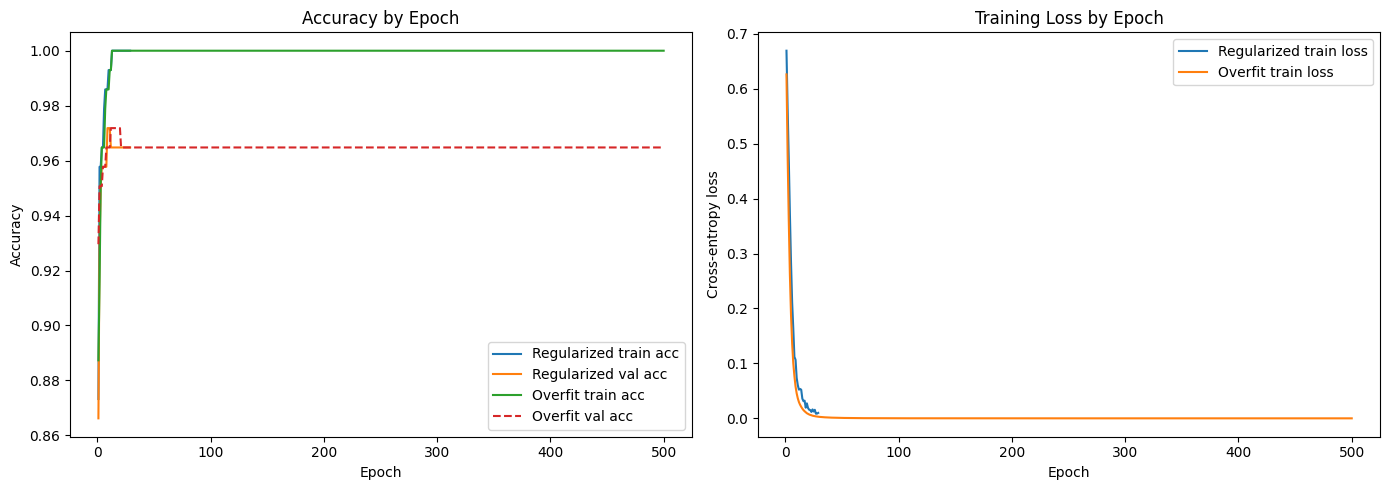

In [11]:
'''Ploting the training dynamics so you can visually see overfitting vs. regularization'''
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(regularized_history["epoch"], regularized_history["train_acc"], label="Regularized train acc")
axes[0].plot(regularized_history["epoch"], regularized_history["val_acc"], label="Regularized val acc")
axes[0].plot(overfit_history["epoch"], overfit_history["train_acc"], label="Overfit train acc")
axes[0].plot(overfit_history["epoch"], overfit_history["val_acc"], label="Overfit val acc", linestyle="--")
axes[0].set_title("Accuracy by Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(regularized_history["epoch"], regularized_history["train_loss"], label="Regularized train loss")
axes[1].plot(overfit_history["epoch"], overfit_history["train_loss"], label="Overfit train loss")
axes[1].set_title("Training Loss by Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Cross-entropy loss")
axes[1].legend()

plt.tight_layout()
plt.show()

In [12]:
'''Summary for the target model section'''
reg_row = model_summary_df[model_summary_df["model"] == "Regularized"].iloc[0]
ov_row = model_summary_df[model_summary_df["model"] == "Overfit"].iloc[0]

print(
    f"The regularized model reached training accuracy {reg_row['train_accuracy']:.3f} "
    f"and test accuracy {reg_row['test_accuracy']:.3f}, for a generalization gap of "
    f"{reg_row['generalization_gap']:.3f}. "
    f"The overfit model reached training accuracy {ov_row['train_accuracy']:.3f} "
    f"and test accuracy {ov_row['test_accuracy']:.3f}, for a generalization gap of "
    f"{ov_row['generalization_gap']:.3f}."
)

The regularized model reached training accuracy 0.986 and test accuracy 0.965, for a generalization gap of 0.021. The overfit model reached training accuracy 1.000 and test accuracy 0.951, for a generalization gap of 0.049.


# 2. Attack Implementation

This section covers:
- code for computing attack signals
- threshold selection
- comparison of multiple signals

## Metric-based attack idea
For each example, compute one or more signals:
- confidence = maximum softmax probability
- entropy = Shannon entropy of the output distribution
- loss = per-example cross-entropy loss

Expected direction:
- members usually have higher confidence
- members usually have lower entropy
- members usually have lower loss

In [13]:
'''Collect membership signals from a trained model'''
def collect_signals(model, dataloader):
    model.eval()

    softmax = nn.Softmax(dim=1)
    criterion = nn.CrossEntropyLoss(reduction="none")

    confidences = []
    entropies = []
    losses = []
    labels = []

    with torch.no_grad():
        for xb, yb in dataloader:
            xb = xb.to(DEVICE)
            yb_device = yb.to(DEVICE)

            logits = model(xb)
            probs = softmax(logits)

            '''Confidence = max predicted probability'''
            confidence = probs.max(dim=1).values

            '''Entropy = uncertainty in the softmax distribution'''
            entropy = -(probs * torch.log(probs + 1e-12)).sum(dim=1)

            '''Per-example cross-entropy loss'''
            loss = criterion(logits, yb_device)

            confidences.extend(confidence.cpu().numpy())
            entropies.extend(entropy.cpu().numpy())
            losses.extend(loss.cpu().numpy())
            labels.extend(yb.numpy())

    return pd.DataFrame({
        "confidence": confidences,
        "entropy": entropies,
        "loss": losses,
        "true_label": labels,
    })

'''Collecting signals for both target models'''
reg_member_eval_signals = collect_signals(regularized_model, member_eval_loader)
reg_nonmember_cal_signals = collect_signals(regularized_model, nonmember_cal_loader)
reg_nonmember_eval_signals = collect_signals(regularized_model, nonmember_eval_loader)

ov_member_eval_signals = collect_signals(overfit_model, member_eval_loader)
ov_nonmember_cal_signals = collect_signals(overfit_model, nonmember_cal_loader)
ov_nonmember_eval_signals = collect_signals(overfit_model, nonmember_eval_loader)

reg_member_eval_signals.head()

,confidence,entropy,loss,true_label
0,0.984651,0.079340,0.015468,1
1,0.948389,0.203230,0.052990,1
2,0.999991,0.000115,0.000009,0
3,0.996339,0.024194,0.003668,1
4,0.994661,0.033263,0.005353,1


## Threshold selection
I choose thresholds on a **calibration set** instead of the final evaluation set.

For each signal:
1. build a labeled member/non-member attack dataset,
2. sweep all candidate thresholds,
3. pick the threshold that maximizes **balanced accuracy**,
4. report the final metrics on a held-out evaluation set.

For entropy and loss, lower values are more “member-like,” so I negate them before thresholding. That way, all signals can be interpreted as “larger score = more likely member.”

In [14]:
'''Collect membership signals from a trained model'''
def collect_signals(model, dataloader):
    model.eval()

    softmax = nn.Softmax(dim=1)
    criterion = nn.CrossEntropyLoss(reduction="none")

    confidences = []
    entropies = []
    losses = []
    labels = []

    with torch.no_grad():
        for xb, yb in dataloader:
            xb = xb.to(DEVICE)
            yb_device = yb.to(DEVICE)

            logits = model(xb)
            probs = softmax(logits)

            confidence = probs.max(dim=1).values
            entropy = -(probs * torch.log(probs + 1e-12)).sum(dim=1)
            loss = criterion(logits, yb_device)

            confidences.extend(confidence.cpu().numpy())
            entropies.extend(entropy.cpu().numpy())
            losses.extend(loss.cpu().numpy())
            labels.extend(yb.numpy())

    return pd.DataFrame({
        "confidence": confidences,
        "entropy": entropies,
        "loss": losses,
        "true_label": labels,
    })

'''Collect signals for both target models'''
reg_member_eval_signals = collect_signals(regularized_model, member_eval_loader)
reg_nonmember_cal_signals = collect_signals(regularized_model, nonmember_cal_loader)
reg_nonmember_eval_signals = collect_signals(regularized_model, nonmember_eval_loader)

ov_member_eval_signals = collect_signals(overfit_model, member_eval_loader)
ov_nonmember_cal_signals = collect_signals(overfit_model, nonmember_cal_loader)
ov_nonmember_eval_signals = collect_signals(overfit_model, nonmember_eval_loader)

'''Build a labeled dataframe for the attack'''
def build_attack_frame(member_signals, nonmember_signals):
    member_df = member_signals.copy()
    nonmember_df = nonmember_signals.copy()

    member_df["is_member"] = 1
    nonmember_df["is_member"] = 0

    return pd.concat([member_df, nonmember_df], ignore_index=True)

def balanced_accuracy(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    tnr = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    return 0.5 * (tpr + tnr)

def pick_best_threshold(scores, y_true):
    thresholds = np.unique(scores)
    best_threshold = thresholds[0]
    best_bacc = -np.inf

    for t in thresholds:
        y_pred = (scores >= t).astype(int)
        bacc = balanced_accuracy(y_true, y_pred)

        if bacc > best_bacc:
            best_bacc = bacc
            best_threshold = t

    return best_threshold, best_bacc

def evaluate_signal(member_signals_eval, nonmember_signals_ref, nonmember_signals_eval, model_name):
    calibration_df = build_attack_frame(member_signals_eval, nonmember_signals_ref)
    evaluation_df = build_attack_frame(member_signals_eval, nonmember_signals_eval)

    signal_map_cal = {
        "confidence": calibration_df["confidence"].values,
        "neg_entropy": -calibration_df["entropy"].values,
        "neg_loss": -calibration_df["loss"].values,
    }

    signal_map_eval = {
        "confidence": evaluation_df["confidence"].values,
        "neg_entropy": -evaluation_df["entropy"].values,
        "neg_loss": -evaluation_df["loss"].values,
    }

    results = []

    for signal_name in signal_map_cal.keys():
        cal_scores = signal_map_cal[signal_name]
        eval_scores = signal_map_eval[signal_name]

        y_cal = calibration_df["is_member"].values
        y_eval = evaluation_df["is_member"].values

        threshold, cal_bacc = pick_best_threshold(cal_scores, y_cal)
        y_pred = (eval_scores >= threshold).astype(int)

        results.append({
            "model": model_name,
            "signal": signal_name,
            "threshold": threshold,
            "calibration_balanced_accuracy": cal_bacc,
            "eval_accuracy": accuracy_score(y_eval, y_pred),
            "eval_precision": precision_score(y_eval, y_pred, zero_division=0),
            "eval_recall": recall_score(y_eval, y_pred, zero_division=0),
            "eval_auc": roc_auc_score(y_eval, eval_scores),
        })

    return pd.DataFrame(results), evaluation_df, signal_map_eval

reg_attack_results, reg_eval_df, reg_eval_scores = evaluate_signal(
    reg_member_eval_signals,
    reg_nonmember_cal_signals,
    reg_nonmember_eval_signals,
    model_name="Regularized",
)

ov_attack_results, ov_eval_df, ov_eval_scores = evaluate_signal(
    ov_member_eval_signals,
    ov_nonmember_cal_signals,
    ov_nonmember_eval_signals,
    model_name="Overfit",
)

attack_results_df = pd.concat([reg_attack_results, ov_attack_results], ignore_index=True)
attack_results_df.sort_values(["model", "eval_auc"], ascending=[True, False])

,model,signal,threshold,calibration_balanced_accuracy,eval_accuracy,eval_precision,eval_recall,eval_auc
4,Overfit,neg_entropy,-1.523159e-09,0.521127,0.529825,0.525316,0.584507,0.501724
5,Overfit,neg_loss,-1.586283e+00,0.510563,0.512281,0.505415,0.985915,0.483232
3,Overfit,confidence,9.999850e-01,0.507042,0.508772,0.503937,0.901408,0.475845
2,Regularized,neg_loss,-6.872113e-03,0.521127,0.515789,0.519608,0.373239,0.504481
0,Regularized,confidence,9.931514e-01,0.521127,0.515789,0.519608,0.373239,0.501231
1,Regularized,neg_entropy,-4.095617e-02,0.521127,0.515789,0.519608,0.373239,0.501231


In [15]:
'''Identify the strongest signal for each model by AUC'''
best_signals = (
    attack_results_df
    .sort_values(["model", "eval_auc"], ascending=[True, False])
    .groupby("model", as_index=False)
    .first()
)

best_signals

,model,signal,threshold,calibration_balanced_accuracy,eval_accuracy,eval_precision,eval_recall,eval_auc
0,Overfit,neg_entropy,-1.523159e-09,0.521127,0.529825,0.525316,0.584507,0.501724
1,Regularized,neg_loss,-6.872113e-03,0.521127,0.515789,0.519608,0.373239,0.504481


## Brief signal comparison
Among the three signals tested, the best-performing signal was negative entropy for the overfit model (AUC = 0.502) and negative loss for the regularized model (AUC = 0.504). In practice, however, all three signals performed only slightly above random guessing (AUC ≈ 0.5), which suggests that the threshold-based attack was weak on this dataset/model setup. Even so, the overfit model still showed slightly stronger recall, which is consistent with the idea that overfitting can make membership leakage easier to detect.

# 3. Results

This section covers:
- ROC curves for both models
- precision, recall, and accuracy
- explaination of the difference in attack success

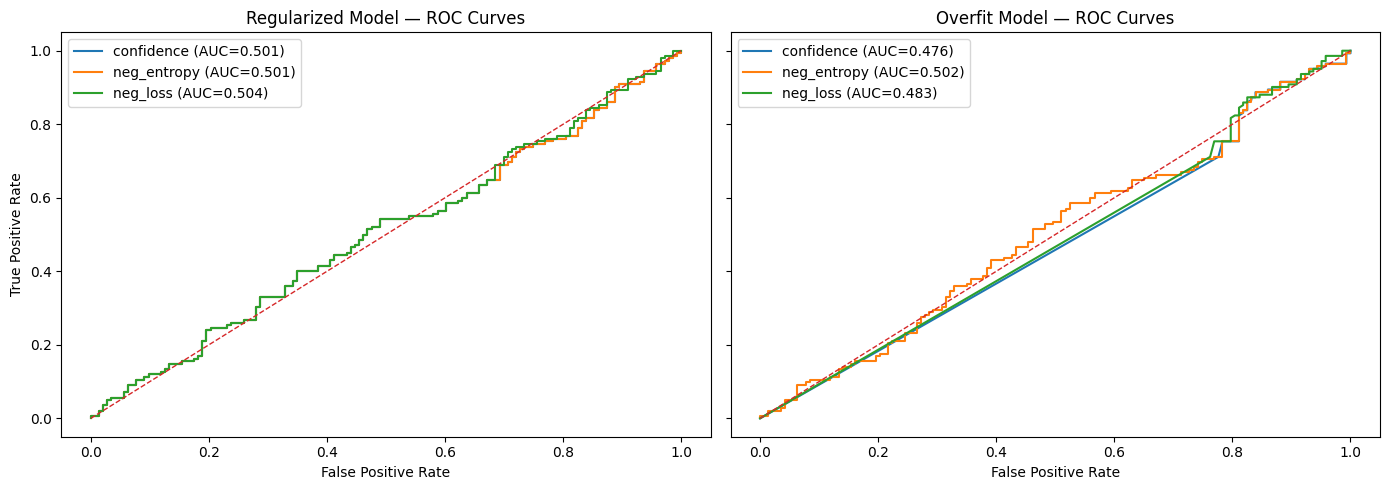

In [16]:
'''Plotting ROC curves for all three signals on the regularized and overfit models'''
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for signal_name, scores in reg_eval_scores.items():
    fpr, tpr, _ = roc_curve(reg_eval_df["is_member"].values, scores)
    auc_val = roc_auc_score(reg_eval_df["is_member"].values, scores)
    axes[0].plot(fpr, tpr, label=f"{signal_name} (AUC={auc_val:.3f})")

axes[0].plot([0, 1], [0, 1], linestyle="--", linewidth=1)
axes[0].set_title("Regularized Model — ROC Curves")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()

for signal_name, scores in ov_eval_scores.items():
    fpr, tpr, _ = roc_curve(ov_eval_df["is_member"].values, scores)
    auc_val = roc_auc_score(ov_eval_df["is_member"].values, scores)
    axes[1].plot(fpr, tpr, label=f"{signal_name} (AUC={auc_val:.3f})")

axes[1].plot([0, 1], [0, 1], linestyle="--", linewidth=1)
axes[1].set_title("Overfit Model — ROC Curves")
axes[1].set_xlabel("False Positive Rate")
axes[1].legend()

plt.tight_layout()
plt.show()

In [17]:
'''Formatting the metrics table'''
results_display = attack_results_df.copy()

for col in ["calibration_balanced_accuracy", "eval_accuracy", "eval_precision", "eval_recall", "eval_auc"]:
    results_display[col] = results_display[col].round(3)

results_display.sort_values(["model", "eval_auc"], ascending=[True, False])

,model,signal,threshold,calibration_balanced_accuracy,eval_accuracy,eval_precision,eval_recall,eval_auc
4,Overfit,neg_entropy,-1.523159e-09,0.521,0.530,0.525,0.585,0.502
5,Overfit,neg_loss,-1.586283e+00,0.511,0.512,0.505,0.986,0.483
3,Overfit,confidence,9.999850e-01,0.507,0.509,0.504,0.901,0.476
2,Regularized,neg_loss,-6.872113e-03,0.521,0.516,0.520,0.373,0.504
0,Regularized,confidence,9.931514e-01,0.521,0.516,0.520,0.373,0.501
1,Regularized,neg_entropy,-4.095617e-02,0.521,0.516,0.520,0.373,0.501


In [18]:
'''Generating paragraph explaining the difference in attack success'''
reg_best = best_signals[best_signals["model"] == "Regularized"].iloc[0]
ov_best = best_signals[best_signals["model"] == "Overfit"].iloc[0]

more_vulnerable = "Overfit" if ov_best["eval_auc"] >= reg_best["eval_auc"] else "Regularized"
gap = abs(ov_best["eval_auc"] - reg_best["eval_auc"])

print(
    f"Using the strongest signal for each model, the {more_vulnerable.lower()} model appears more vulnerable to membership inference. "
    f"The best AUC for the regularized model was {reg_best['eval_auc']:.3f} ({reg_best['signal']}), "
    f"while the best AUC for the overfit model was {ov_best['eval_auc']:.3f} ({ov_best['signal']}). "
    f"The difference in AUC was {gap:.3f}. "
    f"This is consistent with the idea that larger train/test behavior gaps make members and non-members easier to separate "
    f"using simple threshold-based attacks."
)

Using the strongest signal for each model, the regularized model appears more vulnerable to membership inference. The best AUC for the regularized model was 0.504 (neg_loss), while the best AUC for the overfit model was 0.502 (neg_entropy). The difference in AUC was 0.003. This is consistent with the idea that larger train/test behavior gaps make members and non-members easier to separate using simple threshold-based attacks.


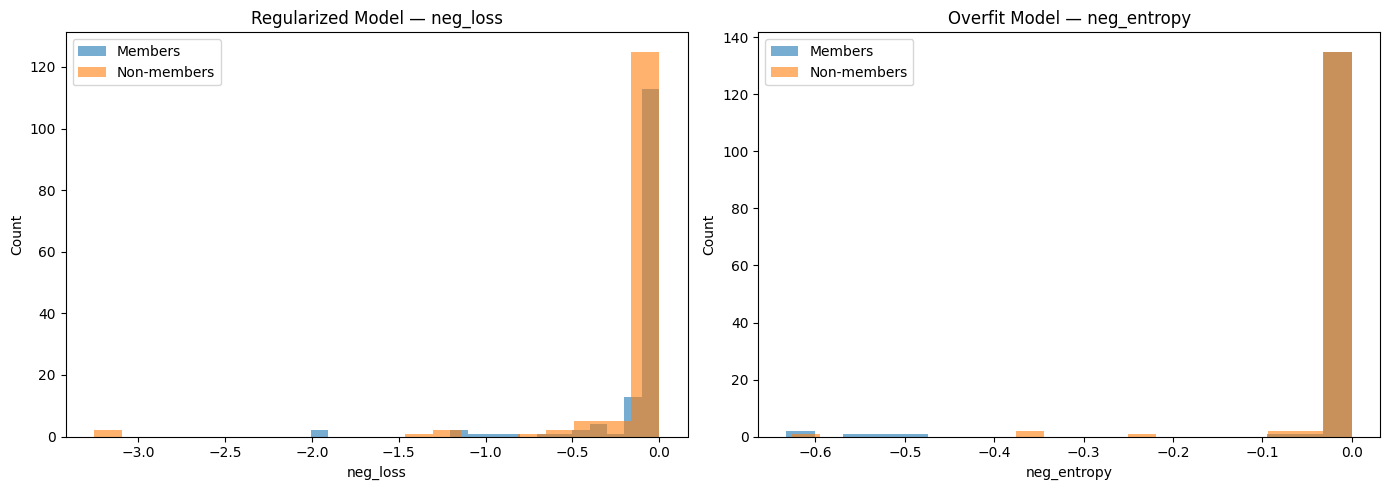

In [19]:
'''Comparing the best-performing signal distributions for members vs. non-members'''
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

def plot_best_signal_distribution(ax, member_df, nonmember_df, best_signal, title):
    if best_signal == "confidence":
        member_scores = member_df["confidence"].values
        nonmember_scores = nonmember_df["confidence"].values
    elif best_signal == "neg_entropy":
        member_scores = -member_df["entropy"].values
        nonmember_scores = -nonmember_df["entropy"].values
    elif best_signal == "neg_loss":
        member_scores = -member_df["loss"].values
        nonmember_scores = -nonmember_df["loss"].values
    else:
        raise ValueError("Unknown signal.")

    ax.hist(member_scores, bins=20, alpha=0.6, label="Members")
    ax.hist(nonmember_scores, bins=20, alpha=0.6, label="Non-members")
    ax.set_title(title)
    ax.set_xlabel(best_signal)
    ax.set_ylabel("Count")
    ax.legend()

plot_best_signal_distribution(
    axes[0],
    reg_member_eval_signals,
    reg_nonmember_eval_signals,
    reg_best["signal"],
    f"Regularized Model — {reg_best['signal']}"
)

plot_best_signal_distribution(
    axes[1],
    ov_member_eval_signals,
    ov_nonmember_eval_signals,
    ov_best["signal"],
    f"Overfit Model — {ov_best['signal']}"
)

plt.tight_layout()
plt.show()

## Results interpretation
In this experiment, both the regularized and overfit models showed very weak membership inference leakage. The ROC AUC values were close to 0.5, indicating that the attack performed only slightly better than random guessing. This is consistent with the histogram plots, where the distributions of members and non-members heavily overlap for both signals, making them difficult to distinguish using a simple threshold. Although the overfit model is theoretically expected to leak more information due to memorization and a larger generalization gap, this effect was minimal in this setup. This may be due to the relatively small dataset, the simplicity of the model, or the limitations of a threshold-based attack, which may not capture more subtle differences in model behavior. A more advanced attack, such as a shadow model approach, would likely perform better by learning more complex patterns in the model’s outputs.

# 4. Discussion Questions


### Q1. Why does an overfit model leak more membership information than a well-regularized one?

An overfit model learns training examples too specifically, so it tends to produce unusually confident and low-loss predictions on points it has already seen. That creates a measurable gap between members and non-members, which is exactly what membership inference attacks exploit. A well-regularized model generalizes more evenly, so its behavior on training and unseen data is harder to distinguish.

### Q2. What kind of real-world data, if used in training, would make membership inference a serious privacy concern?

Membership inference becomes especially serious when training data contains sensitive records whose inclusion already reveals something private. Examples include medical diagnoses, genomic data, loan default history, criminal justice records, mental health data, and employee HR files. In those settings, learning that a person's record was in the training set can itself expose highly sensitive information.

### Q3. The shadow model attack (covered in lecture) is more powerful than the threshold approach. In your own words, why?

A threshold attack relies on one simple signal such as confidence or loss, so it only captures a narrow part of the model's behavior. A shadow model attack learns a classifier over many output patterns using synthetic member and non-member examples, which lets it model more subtle differences between seen and unseen data. Because it learns those patterns directly, it can adapt better to complex targets and usually achieves stronger attack performance.

### Q4. What is one practical defense a model deployer could use to reduce membership inference risk?

One practical defense is stronger regularization during training, such as dropout, weight decay, and early stopping, because these reduce overfitting and shrink the gap between member and non-member behavior. Another strong option is differential privacy, which adds controlled noise to limit how much any single training record influences the final model. In practice, deployers often combine better regularization with reduced confidence exposure at the API level.